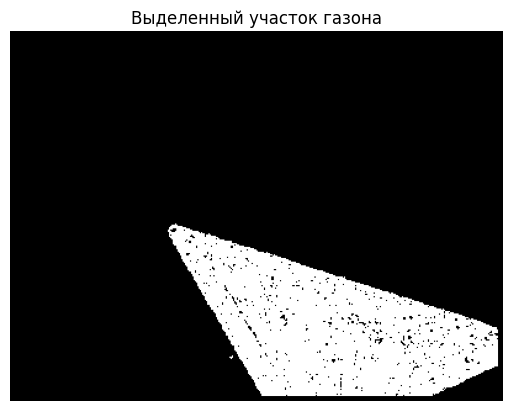

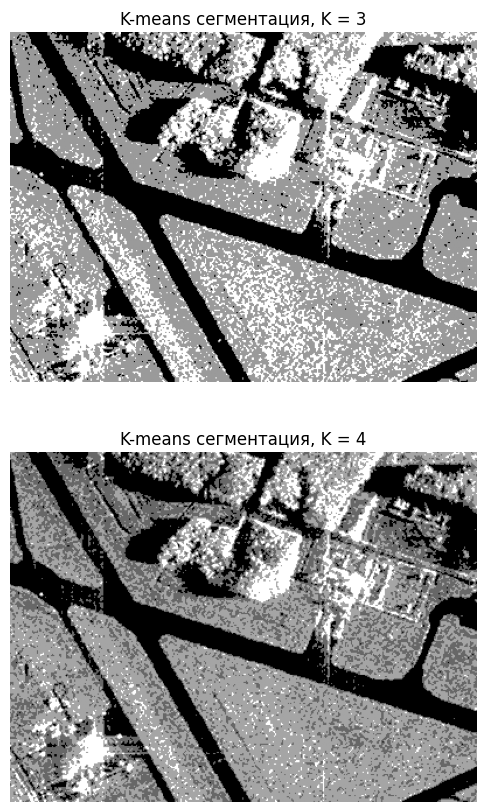

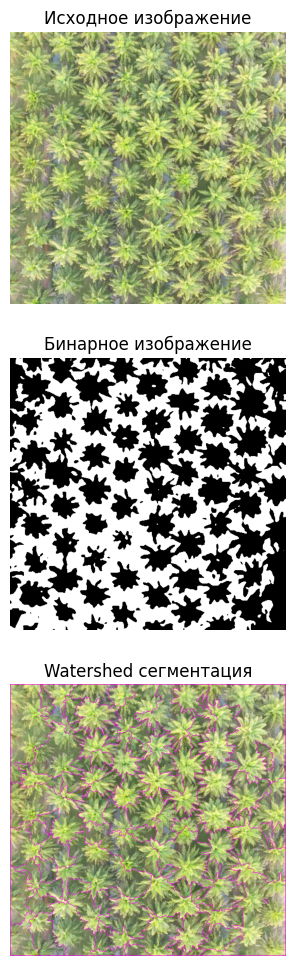

Количество пальм: 100


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src_img = cv2.imread("sar_1.jpg")
gray_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY)

def mean_similarity(gray, current_mask, candidate, threshold):
    region_pixels = gray[current_mask == 1]
    mean_intensity = np.mean(region_pixels)

    if abs(mean_intensity - gray[candidate]) <= threshold:
        return True
    return False


def grow_area(gray, start_point, similarity_func, radius, threshold):
    region_mask = np.zeros(gray.shape, dtype=np.uint8)
    region_mask[start_point] = 1

    pixels_added = True

    while pixels_added:
        pixels_added = False
        temp_mask = np.zeros_like(region_mask)

        for x in range(radius, gray.shape[0] - radius):
            for y in range(radius, gray.shape[1] - radius):
                if region_mask[x, y] == 0:
                    neighborhood = region_mask[x-radius:x+radius, y-radius:y+radius]
                    if neighborhood.sum() > 0:
                        if similarity_func(gray, region_mask, (x, y), threshold):
                            temp_mask[x, y] = 1
                            pixels_added = True

        region_mask = region_mask | temp_mask

    return region_mask * 255


seed = (250, 250)
neighborhood_radius = 4
similarity_threshold = 18

lawn_mask = grow_area(
    gray_img,
    seed,
    mean_similarity,
    neighborhood_radius,
    similarity_threshold
)

plt.imshow(lawn_mask, cmap="gray")
plt.title("Выделенный участок газона")
plt.axis("off")
plt.show()


import cv2
import numpy as np
import matplotlib.pyplot as plt

src_img = cv2.imread("sar_1.jpg")
gray_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY)

pixels = gray_img.reshape((-1, 1))
pixels = np.float32(pixels)

stop_criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    10,
    1.0
)

plt.figure(figsize=(14, 10))

for idx, clusters in enumerate([3, 4], start=1):
    _, labels, centers = cv2.kmeans(
        pixels,
        clusters,
        None,
        stop_criteria,
        10,
        cv2.KMEANS_RANDOM_CENTERS
    )

    centers = np.uint8(centers)
    segmented = centers[labels.flatten()]
    segmented = segmented.reshape(gray_img.shape)

    plt.subplot(2, 1, idx)
    plt.imshow(segmented, cmap="gray")
    plt.title(f"K-means сегментация, K = {clusters}")
    plt.axis("off")

plt.show()


import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

palm_img = cv2.imread("palm_1.jpg")
gray_palm = cv2.cvtColor(palm_img, cv2.COLOR_BGR2GRAY)

smoothed = cv2.GaussianBlur(gray_palm, (13, 13), 0)

_, binary_mask = cv2.threshold(
    smoothed,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

distance_map = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)

local_peaks = ndimage.maximum_filter(distance_map, size=20)

_, foreground = cv2.threshold(
    distance_map,
    0.5 * distance_map.max(),
    255,
    cv2.THRESH_BINARY
)

foreground = foreground.astype(np.uint8)

_, label_map = cv2.connectedComponents(foreground)

watershed_labels = cv2.watershed(palm_img, label_map.astype(np.int32))

palm_count = len(np.unique(watershed_labels)) - 1

result_img = palm_img.copy()
result_img[watershed_labels == -1] = [255, 0, 255]

plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
plt.imshow(cv2.cvtColor(palm_img, cv2.COLOR_BGR2RGB))
plt.title("Исходное изображение")
plt.axis("off")

plt.subplot(3, 1, 2)
plt.imshow(binary_mask, cmap="gray")
plt.title("Бинарное изображение")
plt.axis("off")

plt.subplot(3, 1, 3)
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title("Watershed сегментация")
plt.axis("off")

plt.show()

print("Количество пальм:", palm_count)
